# Carbon-Aware Dispatch Framework
**Carbon-Aware Compute Framework**

Covers Phase 4 of the framework. The goal is to translate the structural
intermittency patterns identified in Phase 3 into an actionable dispatch recommendation:
when and where should flexible AI compute workloads be scheduled to minimise grid carbon
intensity?

All analysis uses `method = 'derived'` from the `carbon_intensity` table. GB is excluded
throughout — see `intermittency_analysis.ipynb` Section F2 for the rationale. Seasonal
stability flags from Phase 3 (Section C4) are carried forward here and used to qualify
dispatch recommendations.

## Sections
- **A. Pre-flight checks** — confirm `carbon_intensity` (derived) is ready and Phase 3 is complete
- **B. Country-hour ranking table** — 5 × 24 combinations ranked by median carbon intensity
- **C. 4-hour block analysis** — 5 × 6 realistic dispatch windows ranked
- **D. Quantified AI workload hook** — headline tonnes CO₂ avoided at 10 MW scale
- **E. Stability check** — how reliably does the top-ranked block hold its position?
- **F. Worst-case stress periods** — weeks when even the best grids fail
- **G. Findings summary** — key dispatch recommendations and methodology notes for portfolio

In [39]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=True)
conn = psycopg2.connect(os.environ["DATABASE_URL"])

def query(sql, params=None):
    return pd.read_sql(sql, conn, params=params)

# Countries in scope — GB excluded (see Phase 3 / Section F2)
COUNTRIES = ['DE_LU', 'ES', 'FR', 'IT']

# Consistent colour palette across all plots
COUNTRY_COLORS = {
    'DE_LU': '#4878CF',  # blue
    'ES':    '#D65F5F',  # red
    'FR':    '#6ACC65',  # green
    'IT':    '#B47CC7',  # purple
}

# 4-hour block labels — used in Sections C, D, E
BLOCK_LABELS = {
    0: '00–04',
    4: '04–08',
    8: '08–12',
    12: '12–16',
    16: '16–20',
    20: '20–24',
}
DAYS_PER_YEAR = 365

mw_slider = widgets.IntSlider(
    value=10, min=0, max=500, step=5,
    description='Capacity (MW):',
    style={'description_width': '140px'},
    layout=widgets.Layout(width='420px')
)

window_slider = widgets.IntSlider(
    value=4, min=1, max=12, step=1,
    description='Window (hours):',
    style={'description_width': '140px'},
    layout=widgets.Layout(width='420px')
)

# Ref - IEA: https://www.iea.org/data-and-statistics/data-tools/energy-and-ai-observatory?tab=Energy+for+AI
scale_label = widgets.HTML(
    value="<span style='color:gray; font-size:0.85em'>"
          "IEA benchmarks: 10–25 MW conventional · 100 MW hyperscale · 1 GW+ campus programme"
          "</span>"
)

display(mw_slider, window_slider, scale_label)

print("DB connected ✓")
print(f"Countries in scope: {COUNTRIES}")
print(f"Dispatch assumption: adjustable via sliders below · default {mw_slider.value} MW, {window_slider.value}h window")
print("IEA benchmarks: 10–25 MW conventional · 100 MW hyperscale · 1 GW+ campus programme")

IntSlider(value=10, description='Capacity (MW):', layout=Layout(width='420px'), max=500, step=5, style=SliderS…

IntSlider(value=4, description='Window (hours):', layout=Layout(width='420px'), max=12, min=1, style=SliderSty…

HTML(value="<span style='color:gray; font-size:0.85em'>IEA benchmarks: 10–25 MW conventional · 100 MW hypersca…

DB connected ✓
Countries in scope: ['DE_LU', 'ES', 'FR', 'IT']
Dispatch assumption: adjustable via sliders below · default 10 MW, 4h window
IEA benchmarks: 10–25 MW conventional · 100 MW hyperscale · 1 GW+ campus programme


---
## Section A — Pre-flight Checks

Confirm that Phase 2 (`carbon_intensity_calculation.ipynb`) and Phase 3
(`intermittency_analysis.ipynb`) are complete before running the dispatch framework.

### A1. Carbon intensity coverage — derived values only

In [5]:
ci_coverage = query("""
    SELECT
        country,
        COUNT(*)                    AS derived_hours,
        MIN(timestamp_utc)::date    AS first_date,
        MAX(timestamp_utc)::date    AS last_date,
        ROUND(MIN(gco2_per_kwh), 1) AS min_gco2,
        ROUND(MAX(gco2_per_kwh), 1) AS max_gco2
    FROM carbon_intensity
    WHERE method  = 'derived'
      AND country != 'GB'
    GROUP BY country
    ORDER BY country
""")

if len(ci_coverage) == 0:
    print("⚠️  carbon_intensity table has no derived rows.")
    print("    Run carbon_intensity_calculation.ipynb (Section B) before proceeding.")
else:
    print(ci_coverage.to_string(index=False))
    missing = [c for c in COUNTRIES if c not in ci_coverage['country'].values]
    if missing:
        print(f"\n⚠️  Countries missing from derived data: {missing}")
    else:
        print("\n✓ All four countries present — proceeding with dispatch analysis.")

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3495033095.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


country  derived_hours first_date  last_date  min_gco2  max_gco2
  DE_LU          21403 2023-12-31 2026-06-10      58.1     556.7
     ES          21368 2023-12-31 2026-06-10      41.1     312.2
     FR          21373 2023-12-31 2026-06-10      17.8     103.0
     IT          21403 2023-12-31 2026-06-10      73.9     481.0

✓ All four countries present — proceeding with dispatch analysis.


### A2. Minimum row count check — at least 8,760 hours (1 full year) per country
The ranking and stability calculations in Sections B–E assume sufficient historical depth.
Below 8,760 hours the percentile-based stability check (Section E) becomes unreliable.

In [ ]:
MIN_HOURS = 8760  # 365 days × 24 hours

for _, row in ci_coverage.iterrows():
    flag = '✓' if row['derived_hours'] >= MIN_HOURS else '⚠️ '
    print(f"{flag} {row['country']}: {int(row['derived_hours']):,} hours  "
          f"({row['first_date']} → {row['last_date']})")

print()
print(f"Minimum required: {MIN_HOURS:,} hours (1 full year).")
print("Countries below threshold: stability percentiles in Section E may be noisy.")

✓ DE_LU: 21,403 hours  (2023-12-31 → 2026-06-10)
✓ ES: 21,368 hours  (2023-12-31 → 2026-06-10)
✓ FR: 21,373 hours  (2023-12-31 → 2026-06-10)
✓ IT: 21,403 hours  (2023-12-31 → 2026-06-10)

Minimum required: 8,760 hours (1 full year).
Countries below threshold: stability percentiles in Section E may be noisy.


---
## Section B — Country-Hour Ranking Table

For each of the 4 × 24 = 96 country-hour combinations (excluding GB), calculate the median carbon
intensity across the full dataset and rank from lowest to highest.

Median is used throughout (not mean) to reduce sensitivity to extreme outlier hours
(grid emergencies, data gaps). Seasonal variants are also calculated to support the
stability qualification in Section E.

### B1. Query — full-year median carbon intensity by country × hour

In [7]:
country_hour_rank = query("""
    WITH ci_by_hour AS (
        SELECT
            country,
            EXTRACT(HOUR FROM timestamp_utc)                               AS hour_utc,
            ROUND(CAST(
                PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
            AS numeric), 1)                                                AS median_gco2,
            ROUND(CAST(
                PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY gco2_per_kwh)
            AS numeric), 1)                                                AS p10_gco2,
            ROUND(CAST(
                PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY gco2_per_kwh)
            AS numeric), 1)                                                AS p90_gco2,
            COUNT(*)                                                       AS obs
        FROM carbon_intensity
        WHERE method  = 'derived'
          AND country != 'GB'
        GROUP BY country, hour_utc
    )
    SELECT
        country,
        hour_utc,
        median_gco2,
        p10_gco2,
        p90_gco2,
        obs,
        RANK() OVER (ORDER BY median_gco2 ASC)                            AS rank_overall
    FROM ci_by_hour
    ORDER BY rank_overall
""")

print(f"Total country-hour combinations: {len(country_hour_rank)}  (expected: {len(COUNTRIES) * 24})")
print()
print("Top 10 cleanest country-hour combinations:")
print(country_hour_rank.head(10).to_string(index=False))
print()
print("Bottom 5 dirtiest country-hour combinations:")
print(country_hour_rank.tail(5).to_string(index=False))

Total country-hour combinations: 96  (expected: 96)

Top 10 cleanest country-hour combinations:
country  hour_utc  median_gco2  p10_gco2  p90_gco2  obs  rank_overall
     FR       3.0         26.7      20.4      42.9  891             1
     FR       2.0         26.8      20.3      43.0  891             2
     FR       1.0         27.2      20.4      43.8  890             3
     FR       4.0         27.2      20.5      44.6  891             3
     FR       5.0         27.3      20.6      51.2  891             5
     FR       0.0         27.4      20.4      46.3  890             6
     FR       6.0         28.5      21.1      57.5  891             7
     FR      23.0         28.7      20.5      52.9  891             8
     FR      16.0         29.3      24.6      61.9  890             9
     FR       7.0         29.4      22.2      61.3  891            10

Bottom 5 dirtiest country-hour combinations:
country  hour_utc  median_gco2  p10_gco2  p90_gco2  obs  rank_overall
     IT      22.0 

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3495033095.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### B2. Visualisation — country × hour heatmap

4 countries × 24 hours coloured by median carbon intensity (gCO₂/kWh).
This is the primary visual for the Tableau Phase 5 heatmap — validate the expected
patterns before building the dashboard:
- France: uniformly dark green (nuclear floor ~30 gCO₂/kWh)
- Germany: strong red band in hours 16–20 UTC (evening gas peakers)
- Spain: midday green band hours 11–15 UTC (solar trough)
- Italy: elevated but with a midday dip in summer quarters

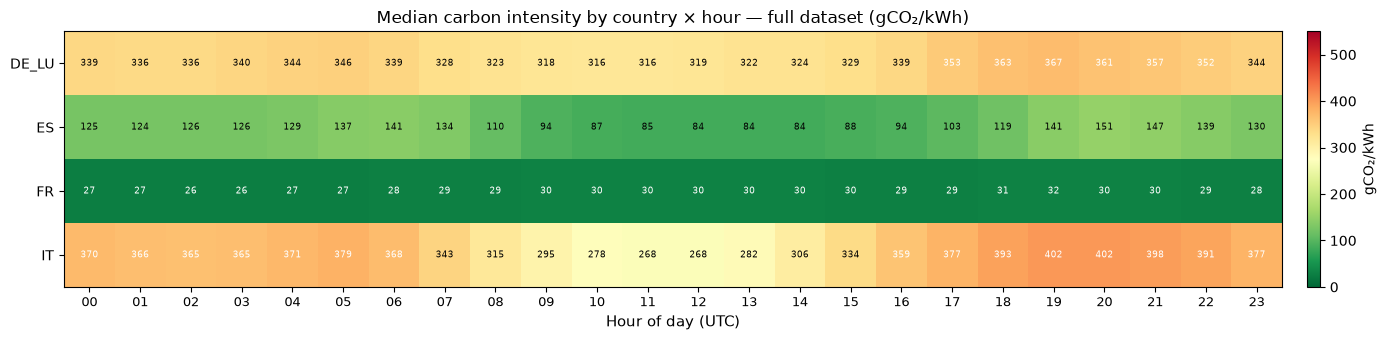


Expected patterns:
  FR — uniformly green row (~30 gCO₂/kWh, nuclear floor)
  ES — green midday band (hours 11–15 UTC, solar)
  DE_LU — red band hours 16–20 UTC (gas peakers)
  IT — elevated overall; modest midday dip visible in full-year median


In [8]:
# Pivot to matrix: rows = countries, columns = hours
heatmap_df = country_hour_rank.pivot(
    index='country', columns='hour_utc', values='median_gco2'
).reindex(COUNTRIES)

fig, ax = plt.subplots(figsize=(14, 3.5))

im = ax.imshow(
    heatmap_df.values,
    aspect='auto',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=550,
)

# Annotate each cell with the rounded value
for i, country in enumerate(heatmap_df.index):
    for j in range(24):
        val = heatmap_df.iloc[i, j]
        if not np.isnan(val):
            text_color = 'white' if val > 350 or val < 80 else 'black'
            ax.text(j, i, f'{int(val)}', ha='center', va='center',
                    fontsize=6.5, color=text_color, fontweight='normal')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=9)
ax.set_yticks(range(len(COUNTRIES)))
ax.set_yticklabels(heatmap_df.index, fontsize=10)
ax.set_xlabel('Hour of day (UTC)', fontsize=11)
ax.set_title('Median carbon intensity by country × hour — full dataset (gCO₂/kWh)', fontsize=12)

cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.015)
cbar.set_label('gCO₂/kWh', fontsize=10)

plt.tight_layout()
plt.show()

print()
print("Expected patterns:")
print("  FR — uniformly green row (~30 gCO₂/kWh, nuclear floor)")
print("  ES — green midday band (hours 11–15 UTC, solar)")
print("  DE_LU — red band hours 16–20 UTC (gas peakers)")
print("  IT — elevated overall; modest midday dip visible in full-year median")

### B3. Per-country trough and peak summary
Identify the single best and worst hour per country — used to frame the dispatch
recommendation narrative in Section G.

In [9]:
print(f"{'Country':<8} {'Best hour (UTC)':<18} {'Median gCO₂/kWh':<20} "
      f"{'Worst hour (UTC)':<18} {'Median gCO₂/kWh'}")
print("-" * 88)

for country in COUNTRIES:
    df_c = country_hour_rank[country_hour_rank['country'] == country]
    best  = df_c.loc[df_c['median_gco2'].idxmin()]
    worst = df_c.loc[df_c['median_gco2'].idxmax()]
    spread = worst['median_gco2'] - best['median_gco2']
    print(f"{country:<8} h{int(best['hour_utc']):02d}              {best['median_gco2']:<20.1f}"
          f"h{int(worst['hour_utc']):02d}              {worst['median_gco2']:.1f}  "
          f"(spread: {spread:.1f})")

Country  Best hour (UTC)    Median gCO₂/kWh      Worst hour (UTC)   Median gCO₂/kWh
----------------------------------------------------------------------------------------
DE_LU    h11              316.5               h19              367.6  (spread: 51.1)
ES       h12              84.3                h20              151.5  (spread: 67.2)
FR       h03              26.7                h19              32.1  (spread: 5.4)
IT       h11              268.8               h20              402.8  (spread: 134.0)


---
## Section C — 4-Hour Block Analysis

Aggregate carbon intensity into 4-hour blocks — the smallest realistic flexible compute
scheduling window for a data centre operator. This reduces the decision space from
96 country-hour pairs to 24 country-block combinations (4 × 6).

Block definitions (UTC):
- `00–04`: overnight, off-peak
- `04–08`: pre-dawn ramp
- `08–12`: morning
- `12–16`: midday (solar peak)
- `16–20`: evening demand peak
- `20–24`: late evening

**Expected finding**: France 00–04 and 04–08 at the top; Germany 16–20 at the bottom.
That contrast is the headline dispatch recommendation.

### C1. Query — median carbon intensity by country × 4-hour block

In [11]:
block_rank = query("""
    WITH ci_blocked AS (
        SELECT
            country,
            (EXTRACT(HOUR FROM timestamp_utc)::int / 4) * 4              AS block_start,
            gco2_per_kwh
        FROM carbon_intensity
        WHERE method  = 'derived'
          AND country != 'GB'
    )
    SELECT
        country,
        block_start,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                   AS median_gco2,
        ROUND(CAST(
            PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                   AS p10_gco2,
        ROUND(CAST(
            PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                   AS p90_gco2,
        COUNT(*)                                                          AS obs,
        RANK() OVER (ORDER BY
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh) ASC) AS rank_overall
    FROM ci_blocked
    GROUP BY country, block_start
    ORDER BY rank_overall
""")

# Add human-readable block label
block_rank['block_label'] = block_rank['block_start'].map(
    lambda h: f"{h:02d}–{(h+4):02d}"
)

print(f"Total country-block combinations: {len(block_rank)}  (expected: {len(COUNTRIES) * 6})")
print()
print("Full ranking — all 24 country-block combinations:")
print(block_rank[['rank_overall', 'country', 'block_label', 'median_gco2',
                   'p10_gco2', 'p90_gco2', 'obs']].to_string(index=False))

Total country-block combinations: 24  (expected: 24)

Full ranking — all 24 country-block combinations:
 rank_overall country block_label  median_gco2  p10_gco2  p90_gco2  obs
            1      FR       00–04         27.1      20.4      44.4 3562
            2      FR       04–08         28.0      20.9      54.8 3564
            3      FR       20–24         29.9      20.8      60.0 3561
            4      FR       16–20         30.3      22.7      63.8 3560
            5      FR       08–12         30.3      24.8      59.0 3564
            6      FR       12–16         30.5      25.8      56.3 3562
            7      ES       12–16         85.6      63.6     121.9 3560
            8      ES       08–12         92.8      66.9     142.3 3564
            9      ES       16–20        114.2      73.4     201.2 3559
           10      ES       00–04        125.8      79.4     193.3 3563
           11      ES       04–08        135.9      82.9     207.4 3564
           12      ES       20–2

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3495033095.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### C2. Visualisation — grouped bar chart by country and block
Shows the dispatch opportunity within each country across the six time blocks.

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3474153077.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(block_lbls, rotation=35, ha='right', fontsize=8)
/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3474153077.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(block_lbls, rotation=35, ha='right', fontsize=8)
/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3474153077.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(block_lbls, rotation=35, ha='right', fontsize=8)
/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/

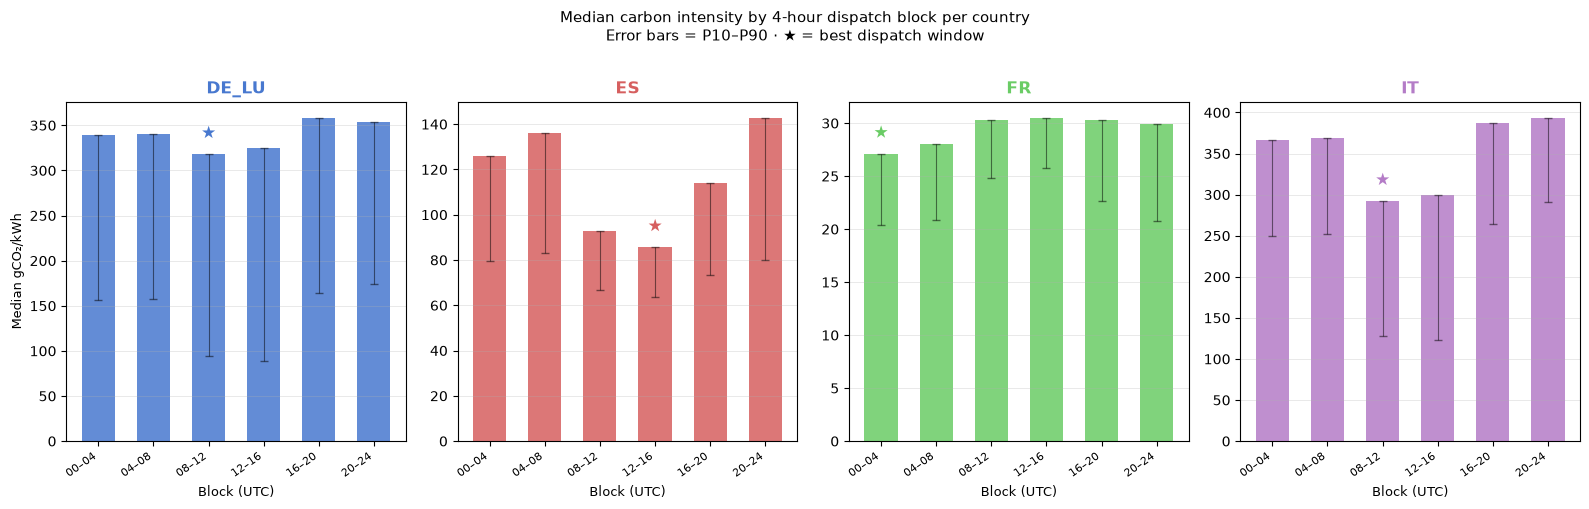

In [13]:
fig, axes = plt.subplots(1, len(COUNTRIES), figsize=(16, 5), sharey=False)

block_order = [0, 4, 8, 12, 16, 20]
block_lbls  = [BLOCK_LABELS[b] for b in block_order]

for ax, country in zip(axes, COUNTRIES):
    df_c = block_rank[block_rank['country'] == country].set_index('block_start')
    vals  = [df_c.loc[b, 'median_gco2'] if b in df_c.index else np.nan for b in block_order]
    p10   = [df_c.loc[b, 'p10_gco2']   if b in df_c.index else np.nan for b in block_order]
    p90   = [df_c.loc[b, 'p90_gco2']   if b in df_c.index else np.nan for b in block_order]

    bars = ax.bar(block_lbls, vals, color=COUNTRY_COLORS[country], alpha=0.85, width=0.6)

    # P10–P90 error bars
    lower = [max(0, v - p) if not (np.isnan(v) or np.isnan(p)) else 0 
            for v, p in zip(vals, p10)]
    upper = [max(0, p - v) if not (np.isnan(v) or np.isnan(p)) else 0 
            for v, p in zip(p90, vals)]
    ax.errorbar(block_lbls, vals, yerr=[lower, upper],
                fmt='none', color='black', capsize=3, linewidth=0.8, alpha=0.5)

    ax.set_title(country, fontsize=12, fontweight='bold',
                 color=COUNTRY_COLORS[country])
    ax.set_xlabel('Block (UTC)', fontsize=9)
    ax.set_ylabel('Median gCO₂/kWh' if country == COUNTRIES[0] else '', fontsize=9)
    ax.set_xticklabels(block_lbls, rotation=35, ha='right', fontsize=8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)
    ax.set_ylim(0, None)

    # Annotate best block
    best_idx = int(np.nanargmin(vals))
    ax.annotate('★', xy=(best_idx, vals[best_idx]),
                xytext=(best_idx, vals[best_idx] + max(vals) * 0.05),
                ha='center', fontsize=12,
                color=COUNTRY_COLORS[country])

plt.suptitle('Median carbon intensity by 4-hour dispatch block per country\n'
             'Error bars = P10–P90 · ★ = best dispatch window', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### C3. Heatmap — cross-country block ranking
Shows relative carbon intensity across all 30 combinations simultaneously.
This is the direct data source for the Tableau dispatch ranking table (Step 21).

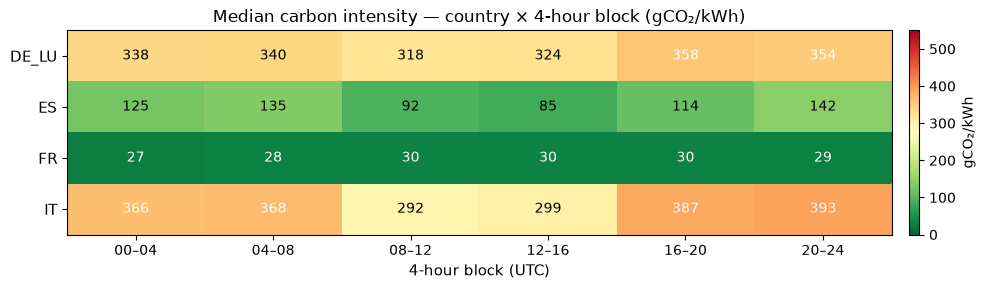

In [14]:
block_pivot = block_rank.pivot(
    index='country', columns='block_start', values='median_gco2'
).reindex(COUNTRIES)[block_order]

fig, ax = plt.subplots(figsize=(10, 3))

im = ax.imshow(
    block_pivot.values,
    aspect='auto',
    cmap='RdYlGn_r',
    vmin=0, vmax=550,
)

for i, country in enumerate(block_pivot.index):
    for j, b in enumerate(block_order):
        val = block_pivot.iloc[i, j]
        text_color = 'white' if val > 350 or val < 80 else 'black'
        ax.text(j, i, f'{int(val)}', ha='center', va='center',
                fontsize=10, color=text_color)

ax.set_xticks(range(6))
ax.set_xticklabels([BLOCK_LABELS[b] for b in block_order], fontsize=10)
ax.set_yticks(range(len(COUNTRIES)))
ax.set_yticklabels(block_pivot.index, fontsize=11)
ax.set_xlabel('4-hour block (UTC)', fontsize=11)
ax.set_title('Median carbon intensity — country × 4-hour block (gCO₂/kWh)', fontsize=12)

cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('gCO₂/kWh', fontsize=10)

plt.tight_layout()
plt.show()

---
## Section D — Quantified AI Workload Hook 

**Formula:**
```
tonnes_co2_avoided = (median_bottom - median_top) × MW × hours × days / 1,000,000
```

Where:
- `median_bottom` = median gCO₂/kWh of the worst-ranked country-block combination
- `median_top`    = median gCO₂/kWh of the best-ranked country-block combination
- `MW`            = data center capacity
- `hours`         = 4-hour flexible window
- `days`          = 365
- `/1,000,000`    = converts gCO₂ → tonnes CO₂

The car-equivalent is calculated at 2,500 kg CO₂/car/year (EU real-world fleet average: ~170g CO2/km x 15,000 km/year; Source: https://www.sciencedirect.com/science/article/pii/S0048969725020947).

### D1. Savings calculation

In [ ]:
top_block    = block_rank.iloc[0]   # lowest median gCO₂/kWh
bottom_block = block_rank.iloc[-1]  # highest median gCO₂/kWh

intensity_top    = float(top_block['median_gco2'])    # gCO₂/kWh
intensity_bottom = float(bottom_block['median_gco2']) # gCO₂/kWh
spread_gco2      = intensity_bottom - intensity_top

# Read from sliders — re-run this cell after adjusting
DATACENTER_MW = mw_slider.value
WINDOW_HOURS  = window_slider.value

# Energy consumed per 4-hour dispatch event
energy_kwh = DATACENTER_MW * 1000 * WINDOW_HOURS  # kWh per event

# Annual tonnes CO₂ avoided by always scheduling in top vs always scheduling in bottom
tonnes_co2_avoided = spread_gco2 * energy_kwh * DAYS_PER_YEAR / 1_000_000

# Car equivalent (~2,500 kg CO₂/car/year)
CAR_KG_CO2_PER_YEAR = 2500
car_equivalent = tonnes_co2_avoided * 1000 / CAR_KG_CO2_PER_YEAR

print("=" * 60)
print("QUANTIFIED DISPATCH IMPACT")
print("=" * 60)
print()
print(f"Best dispatch window:   {top_block['country']} {top_block['block_label']} UTC")
print(f"  Median carbon intensity:  {intensity_top:.1f} gCO₂/kWh")
print()
print(f"Worst dispatch window:  {bottom_block['country']} {bottom_block['block_label']} UTC")
print(f"  Median carbon intensity:  {intensity_bottom:.1f} gCO₂/kWh")
print()
print(f"Carbon intensity spread:    {spread_gco2:.1f} gCO₂/kWh")
print()
print(f"Assumption: {DATACENTER_MW} MW data centre, {WINDOW_HOURS}-hour flexible window, {DAYS_PER_YEAR} days")
print(f"Energy per event:           {energy_kwh:,.0f} kWh")
print()
print(f"Tonnes CO₂ avoided/year:   {tonnes_co2_avoided:,.0f} tCO₂")
print(f"Car equivalent:             {car_equivalent:,.0f} cars off the road for a year")
print()
print("─" * 60)
print("INTERVIEW HEADLINE:")
print(f"  A {DATACENTER_MW} MW data centre saves ~{tonnes_co2_avoided:,.0f} tonnes CO₂/year")
print(f"  by scheduling flexible compute in {top_block['country']} {top_block['block_label']}")
print(f"  rather than {bottom_block['country']} {bottom_block['block_label']} UTC.")
print(f"  Equivalent to taking {car_equivalent:,.0f} cars off EU roads.")
print("─" * 60)

QUANTIFIED DISPATCH IMPACT

Best dispatch window:   FR 00–04 UTC
  Median carbon intensity:  27.1 gCO₂/kWh

Worst dispatch window:  IT 20–24 UTC
  Median carbon intensity:  393.5 gCO₂/kWh

Carbon intensity spread:    366.4 gCO₂/kWh

Assumption: 10 MW data centre, 4-hour flexible window, 365 days
Energy per event:           40,000 kWh

Tonnes CO₂ avoided/year:   5,349 tCO₂
Car equivalent:             2,140 cars off the road for a year

────────────────────────────────────────────────────────────
INTERVIEW HEADLINE:
  A 10 MW data centre saves ~5,349 tonnes CO₂/year
  by scheduling flexible compute in FR 00–04
  rather than IT 20–24 UTC.
  Equivalent to taking 2,140 cars off UK roads.
────────────────────────────────────────────────────────────


### D2. Visualisation — savings across all pairwise country-block comparisons
Shows potential CO₂ savings vs the worst-performing block for each of the top 10
country-block combinations.

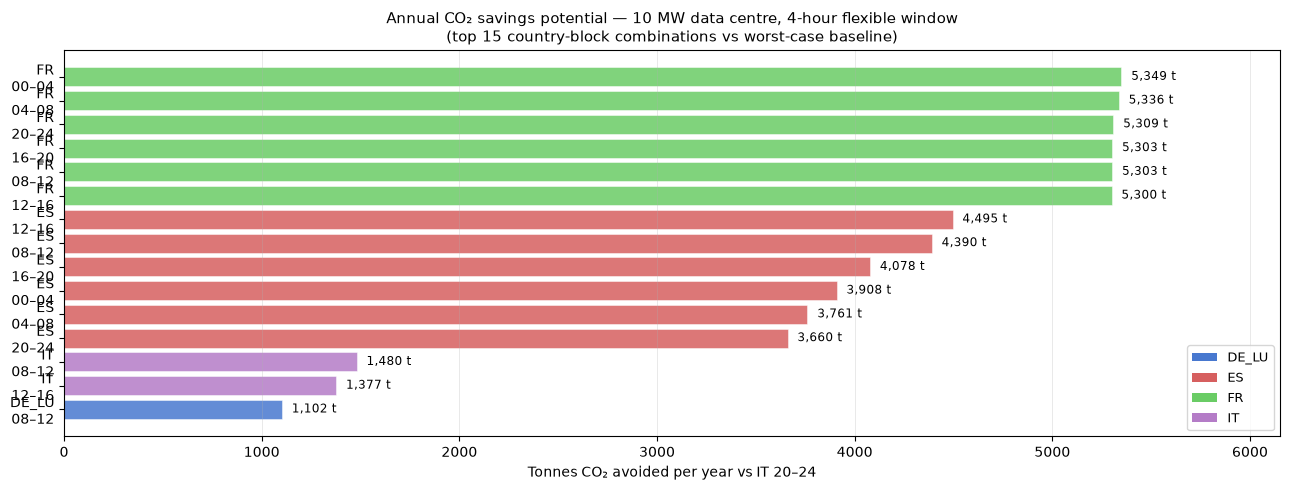

In [18]:
# Calculate savings vs worst block for top-N combinations
TOP_N = 15
top_n = block_rank.head(TOP_N).copy()
top_n['tonnes_saved_vs_worst'] = (
    (intensity_bottom - top_n['median_gco2'])
    * energy_kwh * DAYS_PER_YEAR / 1_000_000
)
top_n['label'] = top_n['country'] + '\n' + top_n['block_label']

fig, ax = plt.subplots(figsize=(13, 5))

bar_colors = [COUNTRY_COLORS[c] for c in top_n['country']]
bars = ax.barh(top_n['label'], top_n['tonnes_saved_vs_worst'],
               color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.4)

# Annotate bars with tonne values
for bar, val in zip(bars, top_n['tonnes_saved_vs_worst']):
    ax.text(val + 50, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} t', va='center', fontsize=8.5)

ax.invert_yaxis()
ax.set_xlabel(f'Tonnes CO₂ avoided per year vs {bottom_block["country"]} {bottom_block["block_label"]}',
              fontsize=10)
ax.set_title(f'Annual CO₂ savings potential — {DATACENTER_MW} MW data centre, '
             f'{WINDOW_HOURS}-hour flexible window\n'
             f'(top {TOP_N} country-block combinations vs worst-case baseline)',
             fontsize=11)
ax.grid(axis='x', linewidth=0.4, alpha=0.5)
ax.set_xlim(0, top_n['tonnes_saved_vs_worst'].max() * 1.15)

# Country legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COUNTRY_COLORS[c], label=c) for c in COUNTRIES]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### D3. Seasonal savings breakdown
The headline figure uses full-year medians. This cell shows whether the ranking and
savings magnitude are consistent across Q1–Q4 — important for a dispatch recommendation
intended to be actionable year-round.

In [20]:
seasonal_blocks = query("""
    WITH ci_blocked AS (
        SELECT
            country,
            EXTRACT(QUARTER FROM timestamp_utc)                          AS quarter,
            (EXTRACT(HOUR FROM timestamp_utc)::int / 4) * 4             AS block_start,
            gco2_per_kwh
        FROM carbon_intensity
        WHERE method  = 'derived'
          AND country != 'GB'
    )
    SELECT
        country,
        quarter,
        block_start,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                  AS median_gco2,
        COUNT(*)                                                         AS obs
    FROM ci_blocked
    GROUP BY country, quarter, block_start
    ORDER BY country, quarter, block_start
""")

seasonal_blocks['block_label'] = seasonal_blocks['block_start'].map(
    lambda h: f"{h:02d}–{(h+4):02d}"
)

# Show how best block's rank changes per quarter for top country
top_country = top_block['country']
top_bstart  = int(top_block['block_start'])

print(f"Seasonal carbon intensity for best block: {top_country} {BLOCK_LABELS[top_bstart]} UTC")
print()
df_top = seasonal_blocks[
    (seasonal_blocks['country'] == top_country) &
    (seasonal_blocks['block_start'] == top_bstart)
].copy()
df_top['quarter_label'] = df_top['quarter'].map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
print(df_top[['quarter_label','median_gco2','obs']].to_string(index=False))

print()
print(f"Seasonal carbon intensity for worst block: {bottom_block['country']} "
      f"{bottom_block['block_label']} UTC")
print()
df_bot = seasonal_blocks[
    (seasonal_blocks['country'] == bottom_block['country']) &
    (seasonal_blocks['block_start'] == int(bottom_block['block_start']))
].copy()
df_bot['quarter_label'] = df_bot['quarter'].map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
print(df_bot[['quarter_label','median_gco2','obs']].to_string(index=False))

# Seasonal spread summary
for q in ['Q1','Q2','Q3','Q4']:
    fr = df_top[df_top['quarter_label']==q]['median_gco2'].values[0]
    it = df_bot[df_bot['quarter_label']==q]['median_gco2'].values[0]
    spread = it - fr
    energy_kwh_val = DATACENTER_MW * 1000 * WINDOW_HOURS
    tonnes = spread * energy_kwh_val * 91 / 1_000_000  # ~91 days per quarter
    print(f"{q}: spread {spread:.1f} gCO₂/kWh → ~{tonnes:,.0f} tCO₂ per quarter")


Seasonal carbon intensity for best block: FR 00–04 UTC

quarter_label  median_gco2  obs
           Q1         34.9 1076
           Q2         21.9 1012
           Q3         22.7  736
           Q4         29.9  738

Seasonal carbon intensity for worst block: IT 20–24 UTC

quarter_label  median_gco2  obs
           Q1        377.9 1084
           Q2        373.0 1008
           Q3        424.9  736
           Q4        406.0  737
Q1: spread 343.0 gCO₂/kWh → ~1,249 tCO₂ per quarter
Q2: spread 351.1 gCO₂/kWh → ~1,278 tCO₂ per quarter
Q3: spread 402.2 gCO₂/kWh → ~1,464 tCO₂ per quarter
Q4: spread 376.1 gCO₂/kWh → ~1,369 tCO₂ per quarter


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/4088519849.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


---
## Section E — Stability Check

The block ranking in Section C is based on medians — it shows the *typical* outcome.
A robust dispatch recommendation also needs to show how *reliably* the top-ranked
blocks hold their position in practice.

**Method**: For each of the top 5 country-block combinations, count the percentage of
actual hours in the dataset where that block genuinely ranked in the top 10 among all
30 combinations — not just the median, but the realised hourly rank.

**Interpretation threshold**:
- ≥ 80%: reliable — safe to recommend without qualification
- 60–79%: usable — recommend with a seasonal qualifier
- < 60%: unreliable — the median is misleading; do not recommend on this basis alone

### E1. Hourly rank distribution — rolling percentile approach

In [21]:
# Pull hourly carbon intensity for all countries and compute per-hour cross-country block rank
hourly_all = query("""
    SELECT
        country,
        DATE_TRUNC('hour', timestamp_utc)                                AS ts_hour,
        (EXTRACT(HOUR FROM timestamp_utc)::int / 4) * 4                 AS block_start,
        gco2_per_kwh
    FROM carbon_intensity
    WHERE method  = 'derived'
      AND country != 'GB'
    ORDER BY ts_hour, country
""")

hourly_all['block_label'] = hourly_all['block_start'].map(
    lambda h: f"{h:02d}–{(h+4):02d}"
)
hourly_all['country_block'] = hourly_all['country'] + ' ' + hourly_all['block_label']

print(f"Loaded {len(hourly_all):,} hourly rows across {len(COUNTRIES)} countries.")

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/4088519849.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Loaded 85,547 hourly rows across 4 countries.


In [24]:
# For each hour, pivot to get one column per country-block, then rank
# Aggregate: for each (date, block_start, country) → mean of the 4 hourly readings in that block
hourly_all['ts_hour'] = pd.to_datetime(hourly_all['ts_hour'], utc=True)

block_daily = (
    hourly_all
    .assign(date=hourly_all['ts_hour'].dt.date)
    .groupby(['date', 'block_start', 'country'])['gco2_per_kwh']
    .mean()
    .reset_index()
)
block_daily['country_block'] = (
    block_daily['country'] + ' '
    + block_daily['block_start'].map(lambda h: f"{h:02d}–{(h+4):02d}")
)

# Pivot: rows = (date, block_start), columns = country_block
pivoted = block_daily.pivot_table(
    index=['date', 'block_start'],
    columns='country_block',
    values='gco2_per_kwh'
).reset_index()

cb_cols = [c for c in pivoted.columns if c not in ['date','block_start']]

# Per-row rank (ascending = lower gCO₂ is rank 1)
pivoted_ranks = pivoted[cb_cols].rank(axis=1, method='min', ascending=True)
pivoted_ranks.columns = cb_cols

print(f"Daily block observations: {len(pivoted):,} rows × {len(cb_cols)} country-block columns")

Daily block observations: 5,352 rows × 24 country-block columns


In [ ]:
# Identify top 5 combinations from Section C median ranking
top5 = [
    f"{row['country']} {row['block_label']}"
    for _, row in block_rank.head(5).iterrows()
]

TOP_N_RANK = 10   # threshold: must rank in top 10 to count as a 'hit'

print(f"Stability check — % of days each top-5 block ranks in top {TOP_N_RANK} of 30 combinations")
print()
print(f"{'Rank':<6} {'Country-block':<18} {'Median gCO₂':<14} "
      f"{'% days in top-10':<20} {'Reliability'}")
print("-" * 80)

stability_results = []
for rank_pos, cb in enumerate(top5, 1):
    if cb not in pivoted_ranks.columns:
        print(f"  {cb}: not found in pivoted data — check country_block label format")
        continue
    total_days   = pivoted_ranks[cb].notna().sum()
    in_top_n     = (pivoted_ranks[cb] <= TOP_N_RANK).sum()
    pct_in_top   = 100 * in_top_n / total_days if total_days > 0 else 0

    if pct_in_top >= 80:
        reliability = '✓ reliable'
    elif pct_in_top >= 60:
        reliability = '⚠️  use with seasonal qualifier'
    else:
        reliability = '✗ unreliable — do not recommend'

    median_val = block_rank.loc[
        block_rank['country'] + ' ' + block_rank['block_label'] == cb,
        'median_gco2'
    ].values
    median_str = f"{median_val[0]:.1f}" if len(median_val) > 0 else 'n/a'

    stability_results.append({
        'country_block': cb, 'pct_in_top': pct_in_top, 'reliability': reliability
    })
    print(f"#{rank_pos:<5} {cb:<18} {median_str:<14} {pct_in_top:<20.1f} {reliability}")

Stability check — % of days each top-5 block ranks in top 10 of 30 combinations

Rank   Country-block      Median gCO₂    % days in top-10     Reliability
--------------------------------------------------------------------------------
#1     FR 00–04           27.1           100.0                ✓ reliable
#2     FR 04–08           28.0           100.0                ✓ reliable
#3     FR 20–24           29.9           100.0                ✓ reliable
#4     FR 16–20           30.3           100.0                ✓ reliable
#5     FR 08–12           30.3           100.0                ✓ reliable


---
## Section F — Worst-Case Stress Periods (Step 18 — Optional)

Identify the 10 worst carbon-intensity weeks per country — periods when wind, solar,
and hydro generation are simultaneously constrained while demand is elevated, forcing
maximum fossil fuel dispatch.

These periods define the reliability ceiling of any dispatch strategy: even the
best-ranked country will occasionally produce high-carbon electricity. Reporting these
dates is analytically honest and demonstrates portfolio-level rigour.

### F1. Query — weekly average carbon intensity, bottom decile per country

In [ ]:
weekly_stress = query("""
    WITH weekly AS (
        SELECT
            country,
            DATE_TRUNC('week', timestamp_utc)::date                      AS week_start,
            ROUND(AVG(gco2_per_kwh), 1)                                  AS weekly_avg_gco2,
            COUNT(*)                                                      AS hours_in_week
        FROM carbon_intensity
        WHERE method  = 'derived'
          AND country != 'GB'
        GROUP BY country, week_start
        HAVING COUNT(*) >= 120   -- at least 5 complete days to avoid partial weeks
    ),
    ranked AS (
        SELECT
            *,
            RANK() OVER (PARTITION BY country ORDER BY weekly_avg_gco2 DESC) AS stress_rank
        FROM weekly
    )
    SELECT *
    FROM ranked
    WHERE stress_rank <= 10
    ORDER BY country, stress_rank
""")

print("Top 10 worst-case weeks per country (highest weekly average carbon intensity):")
print()
for country in COUNTRIES:
    df_c = weekly_stress[weekly_stress['country'] == country]
    if df_c.empty:
        print(f"{country}: no data")
        continue
    print(f"{'─'*50}")
    print(f"  {country}")
    print(f"{'─'*50}")
    for _, row in df_c.iterrows():
        print(f"  #{int(row['stress_rank']):<3} week of {row['week_start']}  "
              f"{row['weekly_avg_gco2']:>7.1f} gCO₂/kWh  "
              f"({int(row['hours_in_week'])} hours)")
    print()

### F2. Visualisation — stress week distribution across the dataset period
Shows *when* high-carbon stress periods cluster — seasonal patterns are visible here.
This is the data behind a potential Tableau 'worst-week' annotation layer.

In [ ]:
fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(14, 2.8 * len(COUNTRIES)),
                         sharex=False)

for ax, country in zip(axes, COUNTRIES):
    # Full weekly series for this country
    full_weekly = query("""
        SELECT
            DATE_TRUNC('week', timestamp_utc)::date AS week_start,
            ROUND(AVG(gco2_per_kwh), 1)             AS weekly_avg_gco2
        FROM carbon_intensity
        WHERE method  = 'derived'
          AND country = %(c)s
        GROUP BY week_start
        HAVING COUNT(*) >= 120
        ORDER BY week_start
    """, params={'c': country})

    full_weekly['week_start'] = pd.to_datetime(full_weekly['week_start'])

    ax.plot(full_weekly['week_start'], full_weekly['weekly_avg_gco2'],
            color=COUNTRY_COLORS[country], linewidth=1.2, alpha=0.8)

    # Overlay stress weeks as red dots
    stress_c = weekly_stress[weekly_stress['country'] == country].copy()
    stress_c['week_start'] = pd.to_datetime(stress_c['week_start'])
    ax.scatter(stress_c['week_start'], stress_c['weekly_avg_gco2'],
               color='red', s=40, zorder=5, label='Stress week (top 10 worst)')

    ax.set_title(f"{country} — weekly average carbon intensity", fontsize=10)
    ax.set_ylabel('gCO₂/kWh', fontsize=9)
    ax.grid(axis='y', linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, None)

plt.suptitle('Worst-case stress weeks by country (red = top-10 highest weekly average)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## Section G — Findings Summary

Key dispatch recommendations and methodology notes for portfolio documentation,
capstone writeup, and Tableau dashboard annotations.

### G1. Dispatch recommendation summary

In [33]:
print("=" * 65)
print("PHASE 4 KEY FINDINGS — CARBON-AWARE DISPATCH FRAMEWORK")
print("=" * 65)
print()
print("RANKING")
print("─" * 65)

print("Full-year country-hour ranking (top 5 country-block combinations):")
for i, (_, row) in enumerate(block_rank.head(5).iterrows(), 1):
    print(f"  #{i}  {row['country']} {row['block_label']} UTC  —  "
          f"{row['median_gco2']:.1f} gCO₂/kWh (P10: {row['p10_gco2']:.1f}, "
          f"P90: {row['p90_gco2']:.1f})")

print()
print("Worst 3 country-block combinations:")
for i, (_, row) in enumerate(block_rank.tail(3).iterrows(), 1):
    print(f"  #{len(block_rank) - 3 + i}  {row['country']} {row['block_label']} UTC  —  "
          f"{row['median_gco2']:.1f} gCO₂/kWh")

print()
print("QUANTIFIED IMPACT")
print("─" * 65)
print(f"  Optimal window:     {top_block['country']} {top_block['block_label']} UTC  "
      f"({intensity_top:.1f} gCO₂/kWh)")
print(f"  Worst-case window:  {bottom_block['country']} {bottom_block['block_label']} UTC  "
      f"({intensity_bottom:.1f} gCO₂/kWh)")
print(f"  Spread:             {spread_gco2:.1f} gCO₂/kWh")
print(f"  At {DATACENTER_MW} MW / {WINDOW_HOURS}-hour window:  {tonnes_co2_avoided:,.0f} tCO₂/year avoided")
print(f"  Car equivalent (EU real-world ~170 g/km × 15,000 km/year = 2,500 kg CO₂):")
print(f"    {car_equivalent:,.0f} cars off the road for a year")
print(f"  Source: JRC OBFCM data (ScienceDirect, 2025)")
print()
print("STABILITY (Step 17)")
print("─" * 65)
for r in stability_results:
    print(f"  {r['country_block']:<18}  {r['pct_in_top']:.1f}% of days in top-10  —  {r['reliability']}")

print()
print("METHODOLOGY NOTES")
print("─" * 65)
print()
print("Production-based carbon intensity:")
print("  All values are derived from ENTSO-E generation mix, not consumption-based.")
print("  For DE_LU, derived values understate consumption-based intensity by ~110 gCO₂/kWh")
print("  (lignite factor + flow-tracing effect). The direction of the dispatch recommendation")
print("  is unaffected — FR remains cleanest in either method.")
print("  Savings figures are a conservative lower bound for DE_LU comparisons.")
print()
print("IT ranking note:")
print("  IT 20–24 ranks as the worst country-block combination on a full-year median basis,")
print("  ranked below DE_LU across all blocks. This reflects production-based methodology:")
print("  IT is a structural net importer; primary interconnections with CH/AT/SI are outside")
print("  dataset scope, causing production-based values to overstate consumer-facing carbon")
print("  intensity. IT Q2 daytime (08–16 UTC) is materially more competitive than the")
print("  full-year median suggests — season matters more than hour for Italy dispatch.")
print()
print("Seasonal qualifications:")
print("  FR    — stable year-round (nuclear floor); Q1 slightly elevated (34.9 vs Q2 21.9)")
print("          due to winter gas peaker dispatch. 2h trough shift is commercially immaterial.")
print("  DE_LU — trough hour shifts from h11 (Q1/Q3/Q4) to h16 (Q2, spring solar).")
print("          Use 09–13 UTC window in Q1/Q3/Q4; 14–17 UTC in Q2.")
print("  ES    — trough shifts 12→15 UTC as CEST advances solar peak. Use 11–16 UTC year-round.")
print("  IT    — depth varies by 167 gCO₂/kWh Q2 vs Q4; Q3 worst-block value peaks at")
print("          424.9 gCO₂/kWh (summer cooling demand, zero solar at 20–24 UTC).")
print()
print("Flexible compute assumption:")
print("  Analysis assumes batch/training workloads with 4-hour scheduling flexibility.")
print("  Does not model real-time inference, minimum uptime constraints, network latency,")
print("  or cross-border regulatory restrictions. Price-taker model — individual datacenter")
print("  decisions assumed not to affect grid carbon intensity.")
print("  IEA benchmark: 10–25 MW = conventional datacenter range (Energy and AI, 2025).")
print()
print("UTC convention:")
print("  All hours are UTC. Operators should convert to local time for scheduling:")
print("  CET = UTC+1, CEST = UTC+2. France 00–04 UTC = 01–05 CET (02–06 CEST).")
print()
print("Outputs feeding into Phase 5 (Tableau):")
print("  Step 19: country × hour heatmap  ← Section B heatmap (B2)")
print("  Step 21: dispatch ranking table  ← Section C full ranking (C1)")
print("  Step 23: carbon savings card     ← Section D headline number (D1)")
print("  Step 24: seasonal toggle         ← Section D3 seasonal block data")

PHASE 4 KEY FINDINGS — CARBON-AWARE DISPATCH FRAMEWORK

RANKING
─────────────────────────────────────────────────────────────────
Full-year country-hour ranking (top 5 country-block combinations):
  #1  FR 00–04 UTC  —  27.1 gCO₂/kWh (P10: 20.4, P90: 44.4)
  #2  FR 04–08 UTC  —  28.0 gCO₂/kWh (P10: 20.9, P90: 54.8)
  #3  FR 20–24 UTC  —  29.9 gCO₂/kWh (P10: 20.8, P90: 60.0)
  #4  FR 16–20 UTC  —  30.3 gCO₂/kWh (P10: 22.7, P90: 63.8)
  #5  FR 08–12 UTC  —  30.3 gCO₂/kWh (P10: 24.8, P90: 59.0)

Worst 3 country-block combinations:
  #22  IT 04–08 UTC  —  368.6 gCO₂/kWh
  #23  IT 16–20 UTC  —  387.2 gCO₂/kWh
  #24  IT 20–24 UTC  —  393.5 gCO₂/kWh

QUANTIFIED IMPACT
─────────────────────────────────────────────────────────────────
  Optimal window:     FR 00–04 UTC  (27.1 gCO₂/kWh)
  Worst-case window:  IT 20–24 UTC  (393.5 gCO₂/kWh)
  Spread:             366.4 gCO₂/kWh
  At 10 MW / 4-hour window:  5,349 tCO₂/year avoided
  Car equivalent (EU real-world ~170 g/km × 15,000 km/year = 2,500 kg

### G2. Methodology notes — carried forward to portfolio documentation

**Production-based vs consumption-based carbon intensity**  
All dispatch analysis uses production-based carbon intensity (`method = 'derived'`) derived
from ENTSO-E generation mix. Consumption-based methods (e.g. Electricity Maps) attribute
imported electricity's carbon to the receiving country. For Germany — a large cross-border
trader with high lignite share — production-based values understate Electricity Maps by
approximately 110 gCO₂/kWh on average. This means the spread between France and Germany
is a **conservative lower bound** for DE_LU comparisons.

For Italy — a structural net importer whose primary interconnections (CH/AT/SI) are outside
dataset scope — production-based values **overstate** consumer-facing carbon intensity.
The full-year median ranking places IT below DE_LU partly for this methodological reason.
IT Q2 daytime competitiveness is understated by the production-based approach.

The direction of the recommendation is robust in either methodology. The quantified
savings figure in Section D should be presented as a floor, not a central estimate.

**Stability is not uniformly distributed**  
Section E provides the % of days a ranked block holds its relative position. A dispatch
recommendation with 90% reliability is operationally meaningful; one with 50% is not.
The stability percentage is a critical disclosure for any real-world application — do not
present the median ranking table without the reliability qualifier.

**Flexible compute and capacity assumptions**  
This analysis assumes batch and training workloads with a 4-hour scheduling window.
It does not model real-time inference requirements, minimum uptime constraints, network
latency, or cross-border regulatory restrictions. The model is price-taker: individual
datacenter scheduling decisions are assumed not to affect grid carbon intensity at scale.
The 10 MW capacity assumption follows IEA's conventional datacenter range of 10–25 MW
(IEA, Energy and AI, 2025). The formula scales linearly — results for other capacities
can be derived proportionally.

**Median vs mean**  
Median is used throughout (not mean) to reduce the influence of extreme outlier hours.
Grid emergencies, ENTSO-E reporting gaps, and curtailment events create fat tails that
make means misleading for planning purposes. P10 and P90 bands in the block chart
(Section C2) are the honest disclosure of that variability.

**Car equivalent benchmark**  
Annual CO₂ savings are expressed as a car equivalent using the EU real-world fleet average
of approximately 2,500 kg CO₂/car/year (170 g/km × 15,000 km/year, JRC OBFCM data, 2025).
This replaces an earlier UK-based figure of 4,600 kg which overstates the EU context.

**Connecting to Phase 5 (Tableau)**  
The outputs of this notebook feed directly into five Tableau views:
- `block_rank` (Section C) → dispatch ranking table
- Headline number (Section D) → carbon savings impact card
- `seasonal_blocks` (Section D3) → seasonal comparison toggle
- `weekly_stress` (Section F) → optional annotation layer on generation mix chart

In [34]:
conn.close()
print("Connection closed.")

Connection closed.


In [36]:
# export to csv
block_rank[['country','block_label','block_start','median_gco2','p10_gco2','p90_gco2','rank_overall']].to_csv('../data/block_rank_p10p90.csv', index=False)

pd.DataFrame(stability_results).to_csv('../data/stability.csv', index=False)

pd.DataFrame([{'intensity_top': intensity_top, 'intensity_bottom': intensity_bottom,
               'spread_gco2': spread_gco2}]).to_csv('../data/kpi_headline.csv', index=False)

In [43]:
generation_week_summer = query("""
    SELECT
        country,
        DATE_TRUNC('hour', timestamp_utc)   AS hour_utc,
        source_type,
        COALESCE(mw, 0)                     AS mw
    FROM generation
    WHERE country != 'GB'
      AND timestamp_utc >= '2026-06-02'
      AND timestamp_utc <  '2026-06-09'
    ORDER BY country, hour_utc, source_type
""")

generation_week_summer.to_csv('../data/generation_week_summer.csv', index=False)
print(f"{len(generation_week_summer)} rows exported")

6888 rows exported


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3569674912.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


In [44]:
generation_week_winter = query("""
    SELECT
        country,
        DATE_TRUNC('hour', timestamp_utc)   AS hour_utc,
        source_type,
        COALESCE(mw, 0)                     AS mw
    FROM generation
    WHERE country != 'GB'
      AND timestamp_utc >= '2026-01-05'
      AND timestamp_utc <  '2026-01-12'
    ORDER BY country, hour_utc, source_type
""")

generation_week_winter.to_csv('../data/generation_week_winter.csv', index=False)
print(f"{len(generation_week_winter)} rows exported")

6888 rows exported


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_79619/3569674912.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


In [49]:
generation_both = pd.concat([generation_week_summer, generation_week_winter], ignore_index=True)
generation_both.to_csv('../data/generation_both.csv', index=False)